In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split

In [2]:
MODEL_NAME = "AE_3"
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
transform = transforms.ToTensor()

# Load full training dataset (60,000 images)
full_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

# 90% train, 10% val (or choose your own split)
train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size

train_data, val_data = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


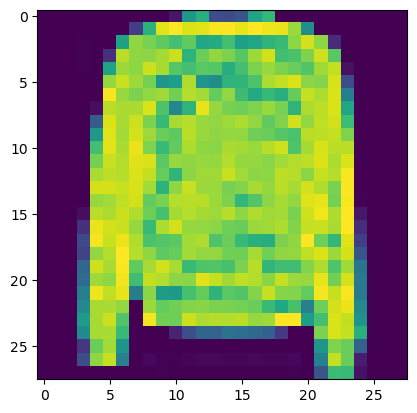

In [6]:
image = images[0]
image = image.permute(1, 2, 0)
plt.imshow(image)

In [8]:
class Reshape(nn.Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape  # this should be the target shape without the batch dim (e.g. (32, 7, 7))

    def forward(self, x):
        return x.view(x.size(0), *self.shape)

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), # 32 x 14 x 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x 3 x 3
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*3*3, 64), # Latent Rep dim. 64
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 128*3*3),
            nn.ReLU(),
            Reshape(128, 3, 3),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 32 x 14 x 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 1 x 28 x 28
            nn.Sigmoid()
        )

    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [9]:
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

In [10]:
def save_checkpoint(model, optimizer, epoch, filename="checkpoint.pth"):
    
    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict()
    }
    
    torch.save(checkpoint, filename)

In [11]:
loss_values = []
val_loss_values = []
num_epoch = []

best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    running_loss = 0.0
    
    # Training Loop

    model.train()
    for (img, _) in train_loader:

        img = img.to(device)

        encoded, decoded = model(img)
        loss = criterion(decoded, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_values.append(epoch_loss)

    # Validation Loop
    
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for (img, _) in val_loader:

            img = img.to(device)

            encoded, decoded = model(img)
            val_loss = criterion(decoded, img)
            val_running_loss += val_loss.item()
    
    epoch_val_loss = val_running_loss / len(val_loader)
    val_loss_values.append(epoch_val_loss)

    num_epoch.append(epoch)
    print(f"Epoch:{epoch+1}, Train Loss:{epoch_loss:.4f}, Val Loss:{epoch_val_loss:.4f}")

    # Save best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        save_checkpoint(model, optimizer, epoch, filename=f"{MODEL_NAME}_best.pth")
        print(f"Best model updated!")

print("Training Complete!")

Epoch:1, Train Loss:0.0324, Val Loss:0.0176
Best model updated!
Epoch:2, Train Loss:0.0157, Val Loss:0.0137
Best model updated!
Epoch:3, Train Loss:0.0131, Val Loss:0.0122
Best model updated!
Epoch:4, Train Loss:0.0116, Val Loss:0.0109
Best model updated!
Epoch:5, Train Loss:0.0107, Val Loss:0.0103
Best model updated!
Epoch:6, Train Loss:0.0099, Val Loss:0.0094
Best model updated!
Epoch:7, Train Loss:0.0094, Val Loss:0.0091
Best model updated!
Epoch:8, Train Loss:0.0090, Val Loss:0.0085
Best model updated!
Epoch:9, Train Loss:0.0086, Val Loss:0.0083
Best model updated!
Epoch:10, Train Loss:0.0083, Val Loss:0.0081
Best model updated!
Epoch:11, Train Loss:0.0080, Val Loss:0.0078
Best model updated!
Epoch:12, Train Loss:0.0077, Val Loss:0.0075
Best model updated!
Epoch:13, Train Loss:0.0076, Val Loss:0.0076
Epoch:14, Train Loss:0.0073, Val Loss:0.0071
Best model updated!
Epoch:15, Train Loss:0.0072, Val Loss:0.0070
Best model updated!
Epoch:16, Train Loss:0.0070, Val Loss:0.0067
Best mode

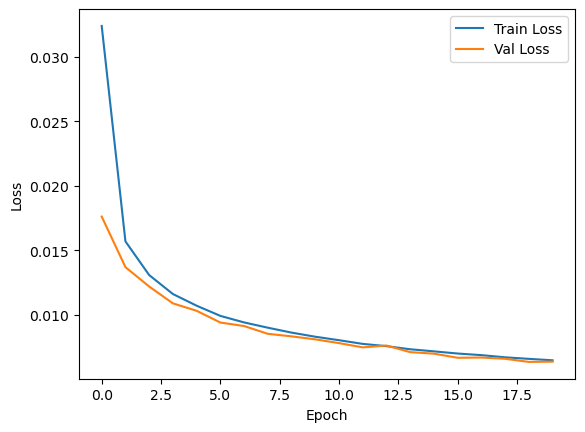

In [12]:
plt.plot(num_epoch, loss_values, label="Train Loss")
plt.plot(num_epoch, val_loss_values, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()